# B2B EdTech Lead Conversion & Sales Analytics
# Python EDA & Business Insights

# Project Objective

The objective of this project is to analyze B2B EdTech lead conversion data and identify the key factors influencing customer conversions.

This analysis focuses on evaluating marketing source performance, lead engagement levels, website activity, and customer interaction patterns to understand conversion behavior.

The insights derived from this analysis can help improve lead targeting strategies, optimize marketing efforts, and enhance overall conversion performance.

In [12]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load Dataset

df = pd.read_csv("clean_b2b_edtech_leads.csv")

df.head()

,Teacher_ID,CRM_Lead_ID,Lead_Acquisition_Type,Marketing_Source,Email_Opt_Out,Call_Opt_Out,Lead_Converted,Total_Website_Visits,Total_Engagement_Time,Avg_Page_Views_Per_Visit,...,City,Engagement_Activity_Level,Customer_Profile_Level,Engagement_Activity_Score,Customer_Profile_Score,Payment_Commitment_Status,Free_Resource_Request,Last_Significant_Interaction,Engagement_Level,High_Intent_Lead
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,Not Specified,02.Medium,02.Medium,15.0,15.0,No,No,Modified,Low,No
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,Not Specified,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened,Low,No
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened,Low,No
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified,Low,No
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified,Low,No


In [14]:
# Dataset Shape

df.shape

(9240, 39)

In [15]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Teacher_ID                         9240 non-null   object 
 1   CRM_Lead_ID                        9240 non-null   int64  
 2   Lead_Acquisition_Type              9240 non-null   object 
 3   Marketing_Source                   9204 non-null   object 
 4   Email_Opt_Out                      9240 non-null   object 
 5   Call_Opt_Out                       9240 non-null   object 
 6   Lead_Converted                     9240 non-null   int64  
 7   Total_Website_Visits               9103 non-null   float64
 8   Total_Engagement_Time              9240 non-null   int64  
 9   Avg_Page_Views_Per_Visit           9103 non-null   float64
 10  Last_Sales_Interaction             9137 non-null   object 
 11  Country                            6779 non-null   objec

In [16]:
# Missing Values

df.isnull().sum().sort_values(ascending=False)

Lead_Quality_Level                   4767
Engagement_Activity_Level            4218
Customer_Profile_Level               4218
Engagement_Activity_Score            4218
Customer_Profile_Score               4218
Lead_Interaction_Status              3353
Lead_Profile_Type                    2709
Primary_Goal_For_Enrollment          2709
Customer_Profile                     2690
Country                              2461
Discovery_Channel                    2207
Course_Interest_Area                 1438
City                                 1420
Avg_Page_Views_Per_Visit              137
Total_Website_Visits                  137
Last_Sales_Interaction                103
Marketing_Source                       36
Payment_Commitment_Status               0
Free_Resource_Request                   0
Last_Significant_Interaction            0
Engagement_Level                        0
DigitalMarketing_Content_Interest       0
SupplyChain_Content_Interest            0
Teacher_ID                        

In [17]:
# Duplicate Check

df.duplicated().sum()

np.int64(0)

In [18]:
# Conversion Distribution

df['Lead_Converted'].value_counts()

Lead_Converted
0    5679
1    3561
Name: count, dtype: int64

In [21]:
# Conversion Rate

conversion_rate = (
    df['Lead_Converted'].mean()*100
)

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 38.54%


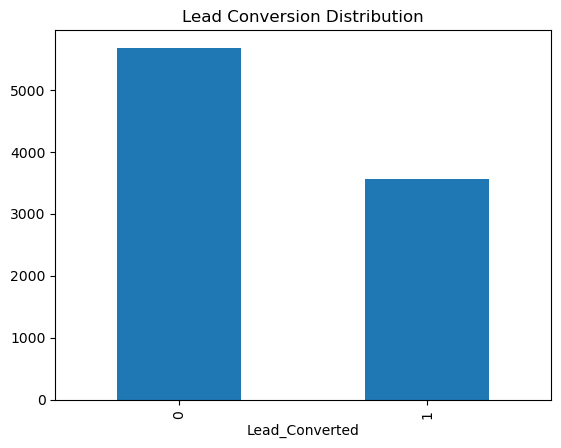

In [22]:
# Conversion Chart

df['Lead_Converted'].value_counts().plot(
    kind='bar'
)

plt.title("Lead Conversion Distribution")
plt.show()

In [25]:
# Marketing Source Analysis

source_analysis = (
    df.groupby('Marketing_Source')
    ['Lead_Converted']
    .agg(['count','sum'])
    .sort_values('count',ascending=False)
)

source_analysis.head(10)

,count,sum
Marketing_Source,,
Google,2868,1147
Direct Traffic,2543,818
Olark Chat,1755,448
Organic Search,1154,436
Reference,534,490
Welingak Website,142,140
Referral Sites,125,31
Facebook,55,13
bing,6,1


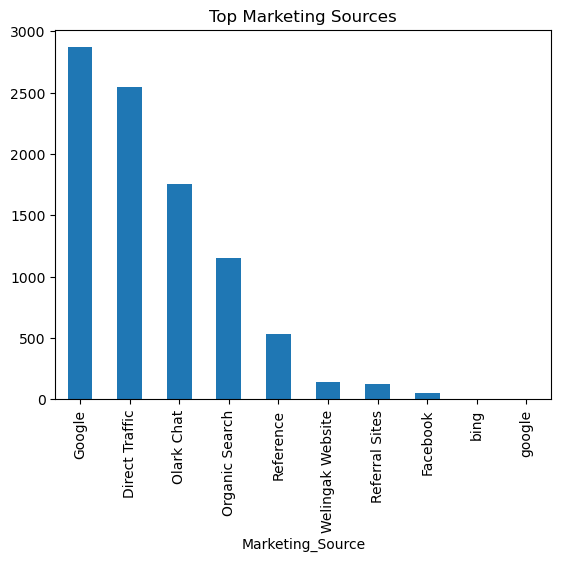

In [26]:
# Top Sources Chart

top_sources = (
    df['Marketing_Source']
    .value_counts()
    .head(10)
)

top_sources.plot(kind='bar')

plt.title("Top Marketing Sources")
plt.show()

In [27]:
# Engagement Level Analysis

pd.crosstab(
    df['Engagement_Level'],
    df['Lead_Converted']
)

Lead_Converted,0,1
Engagement_Level,,
High,188,165
Low,4747,2863
Medium,744,533


In [28]:
# High Intent Leads

pd.crosstab(
    df['High_Intent_Lead'],
    df['Lead_Converted']
)

Lead_Converted,0,1
High_Intent_Lead,,
No,5679,3396
Yes,0,165


In [29]:
# Website Visits Analysis

df.groupby(
    'Lead_Converted'
)['Total_Website_Visits'].mean()

Lead_Converted
0    3.329670
1    3.633632
Name: Total_Website_Visits, dtype: float64

In [30]:
# Engagement Time Analysis

df.groupby(
    'Lead_Converted'
)['Total_Engagement_Time'].mean()

Lead_Converted
0    330.404473
1    738.546757
Name: Total_Engagement_Time, dtype: float64

In [31]:
# Correlation

numeric_cols = df.select_dtypes(
    include=np.number
)

numeric_cols.corr()

,CRM_Lead_ID,Lead_Converted,Total_Website_Visits,Total_Engagement_Time,Avg_Page_Views_Per_Visit,Engagement_Activity_Score,Customer_Profile_Score
CRM_Lead_ID,1.000000,0.025157,0.022223,0.020329,0.058808,-0.067982,-0.129124
Lead_Converted,0.025157,1.000000,0.030395,0.362483,-0.003328,0.167962,0.218571
Total_Website_Visits,0.022223,0.030395,1.000000,0.221240,0.512125,-0.058514,0.130887
Total_Engagement_Time,0.020329,0.362483,0.221240,1.000000,0.320361,-0.065287,0.175589
Avg_Page_Views_Per_Visit,0.058808,-0.003328,0.512125,0.320361,1.000000,-0.162892,0.161254
Engagement_Activity_Score,-0.067982,0.167962,-0.058514,-0.065287,-0.162892,1.000000,-0.123250
Customer_Profile_Score,-0.129124,0.218571,0.130887,0.175589,0.161254,-0.123250,1.000000


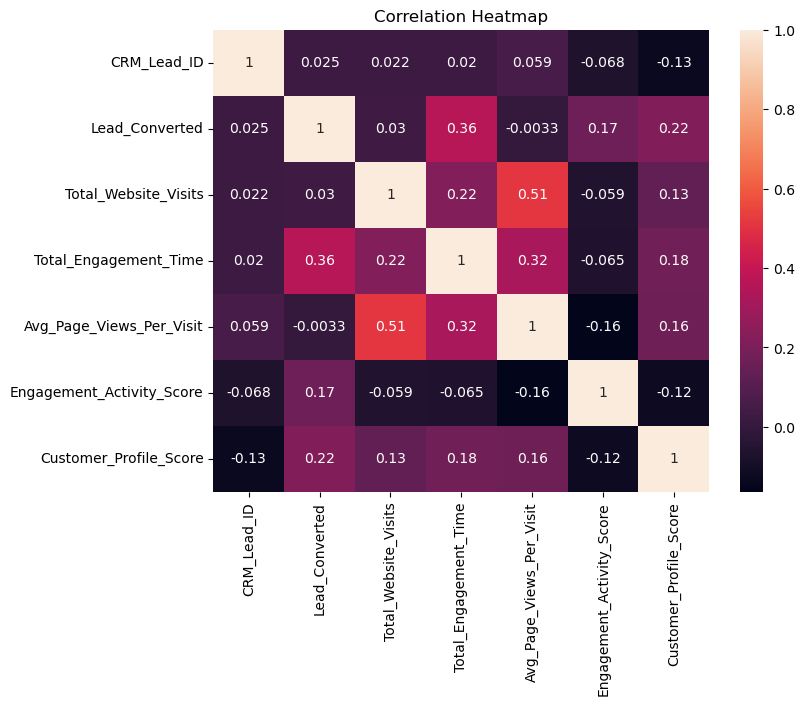

In [32]:
# Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

# Key Insights

1. Google and Direct Traffic generated most leads.

2. Highly engaged leads converted more frequently.

3. Converted leads spent more time on the platform.

4. Website activity positively influenced conversion.

5. Lead quality and engagement were major conversion drivers.


# Conclusion

The analysis identified key factors affecting lead conversion, including marketing channels,
engagement behaviour and website activity.

These insights can help improve lead targeting
and conversion performance.
